In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully")

Libraries imported successfully


In [7]:
file_path = "online_retail_II.xlsx"

In [8]:
file_path = "online_retail_II.xlsx"

df_2009 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

print(df_2009.shape)
print(df_2010.shape)

(525461, 8)
(541910, 8)


In [9]:
df = pd.concat(
    [df_2009, df_2010],
    ignore_index=True
)

print("Dataset shape:", df.shape)

Dataset shape: (1067371, 8)


In [10]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [11]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [12]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[ns]


In [13]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [14]:
df[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [15]:
sales_df = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
].copy()

print("Original rows:", len(df))
print("Valid sales rows:", len(sales_df))

Original rows: 1067371
Valid sales rows: 1041671


In [16]:
print("Total Revenue:", sales_df["Revenue"].sum())

Total Revenue: 20972968.138


In [17]:
sales_df["Month"] = sales_df["InvoiceDate"].dt.to_period("M")

In [18]:
sales_df[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


In [19]:
monthly_revenue = (
    sales_df
    .groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,Month,Revenue
0,2009-12,825685.760
1,2010-01,652708.502
2,2010-02,553713.306
3,2010-03,833570.131
4,2010-04,681528.992


In [20]:
monthly_revenue["Month"] = monthly_revenue["Month"].dt.to_timestamp()

In [21]:
monthly_revenue.head()

,Month,Revenue
0,2009-12-01,825685.760
1,2010-01-01,652708.502
2,2010-02-01,553713.306
3,2010-03-01,833570.131
4,2010-04-01,681528.992


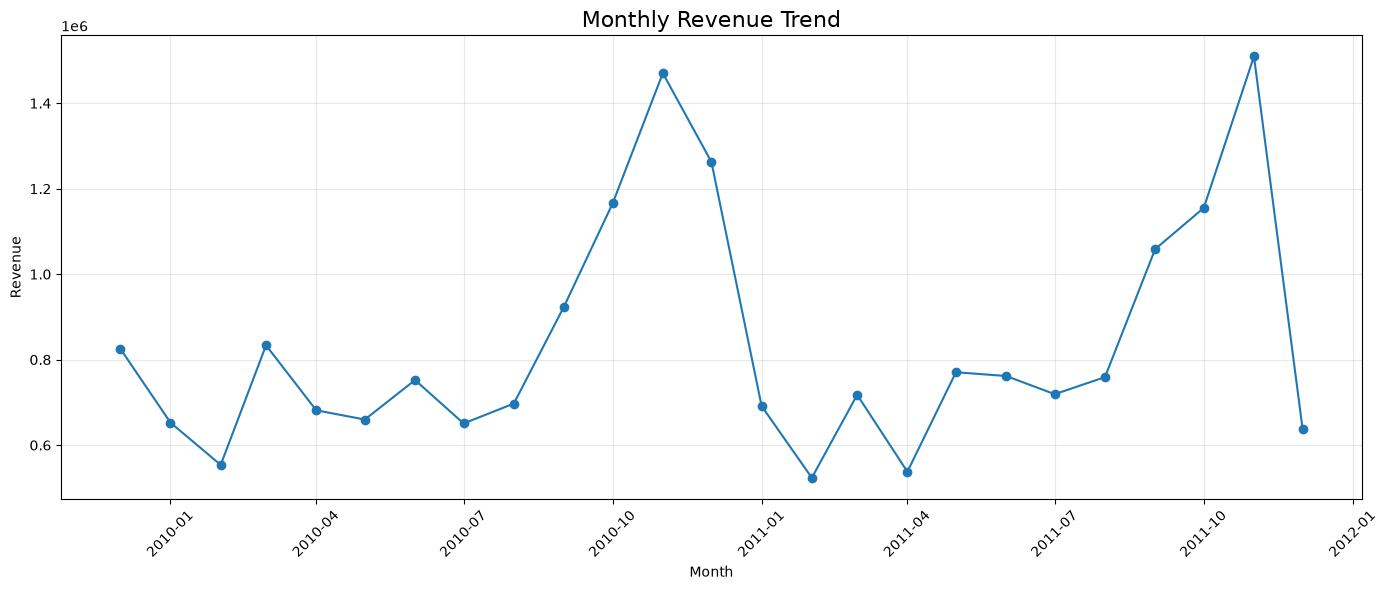

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [24]:
country_revenue = (
    sales_df
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_revenue.head(10)

,Country,Revenue
0,United Kingdom,1.787135e+07
1,EIRE,6.644318e+05
2,Netherlands,5.542323e+05
3,Germany,4.312625e+05
4,France,3.569446e+05
5,Australia,1.699681e+05
6,Spain,1.091785e+05
7,Switzerland,1.010113e+05
8,Sweden,9.190372e+04
9,Denmark,6.986219e+04


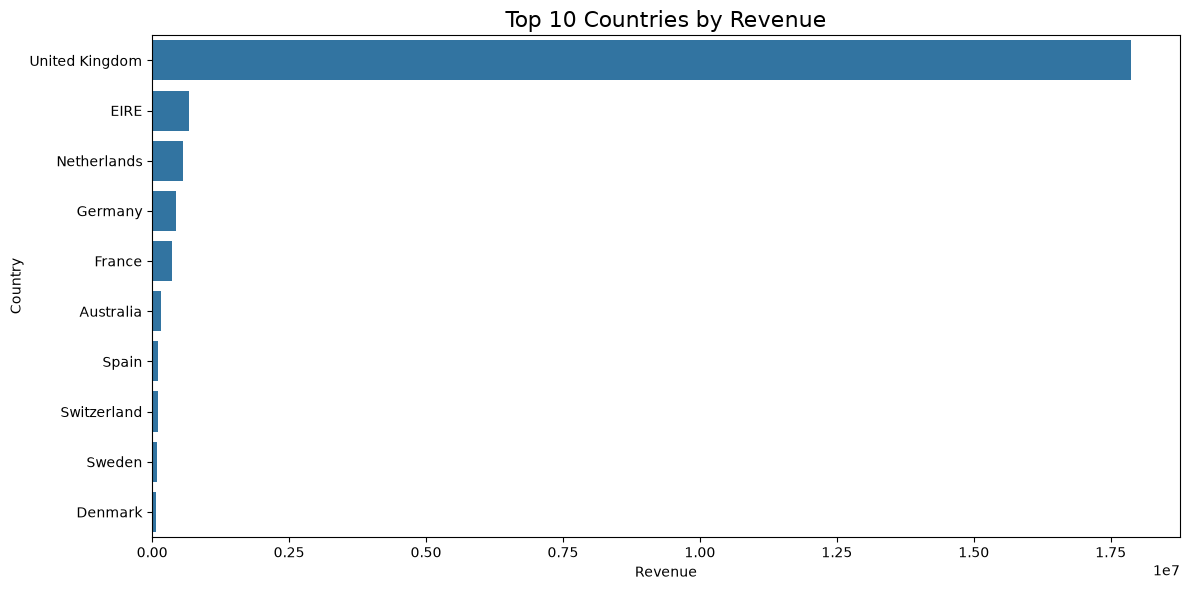

In [25]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=country_revenue.head(10),
    x="Revenue",
    y="Country"
)

plt.title("Top 10 Countries by Revenue", fontsize=16)
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [26]:
product_revenue = (
    sales_df
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_revenue.head(10)

,Description,Revenue
0,REGENCY CAKESTAND 3 TIER,344563.25
1,Manual,341104.90
2,DOTCOM POSTAGE,322657.48
3,WHITE HANGING HEART T-LIGHT HOLDER,266923.55
4,"PAPER CRAFT , LITTLE BIRDIE",168469.60
5,JUMBO BAG RED RETROSPOT,150935.56
6,PARTY BUNTING,149187.05
7,ASSORTED COLOUR BIRD ORNAMENT,132187.92
8,POSTAGE,127597.42
9,PAPER CHAIN KIT 50'S CHRISTMAS,123141.54


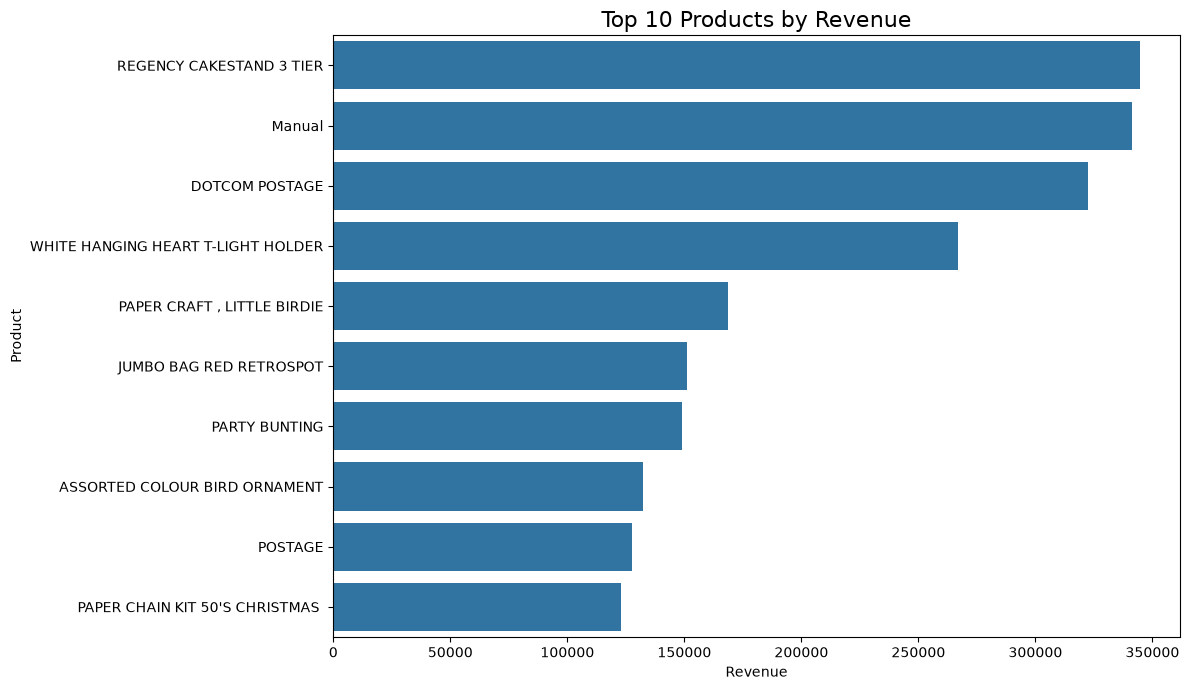

In [27]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=product_revenue.head(10),
    x="Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue", fontsize=16)
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [30]:
sales_df["Day"] = sales_df["InvoiceDate"].dt.day_name()

In [31]:
sales_df["Hour"] = sales_df["InvoiceDate"].dt.hour

In [32]:
activity = (
    sales_df
    .groupby(["Day", "Hour"])
    .size()
    .reset_index(name="Transactions")
)

activity.head()

,Day,Hour,Transactions
0,Friday,7,183
1,Friday,8,3257
2,Friday,9,12908
3,Friday,10,16544
4,Friday,11,19687


In [33]:
heatmap_data = activity.pivot(
    index="Day",
    columns="Hour",
    values="Transactions"
)

heatmap_data

Hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Day,,,,,,,,,,,,,,,
Friday,NaN,183.0,3257.0,12908.0,16544.0,19687.0,20802.0,18665.0,21302.0,15999.0,10732.0,8686.0,631.0,89.0,8.0
Monday,NaN,156.0,2971.0,15412.0,17503.0,19093.0,25578.0,26574.0,22560.0,22818.0,17011.0,13315.0,1924.0,NaN,NaN
Saturday,NaN,NaN,NaN,NaN,30.0,4.0,102.0,101.0,56.0,70.0,37.0,NaN,NaN,NaN,NaN
Sunday,NaN,NaN,NaN,80.0,8945.0,23058.0,28764.0,25852.0,20617.0,21438.0,9305.0,71.0,NaN,NaN,NaN
Thursday,1.0,290.0,3064.0,13574.0,17102.0,18199.0,25205.0,25152.0,25483.0,20542.0,18738.0,10627.0,9102.0,8160.0,2013.0
Tuesday,NaN,254.0,2921.0,13326.0,15485.0,18680.0,27893.0,26665.0,23781.0,26797.0,19278.0,11046.0,4517.0,285.0,9.0
Wednesday,NaN,181.0,3467.0,11724.0,15018.0,19670.0,28193.0,24290.0,24696.0,24726.0,16543.0,11844.0,159.0,15.0,18.0


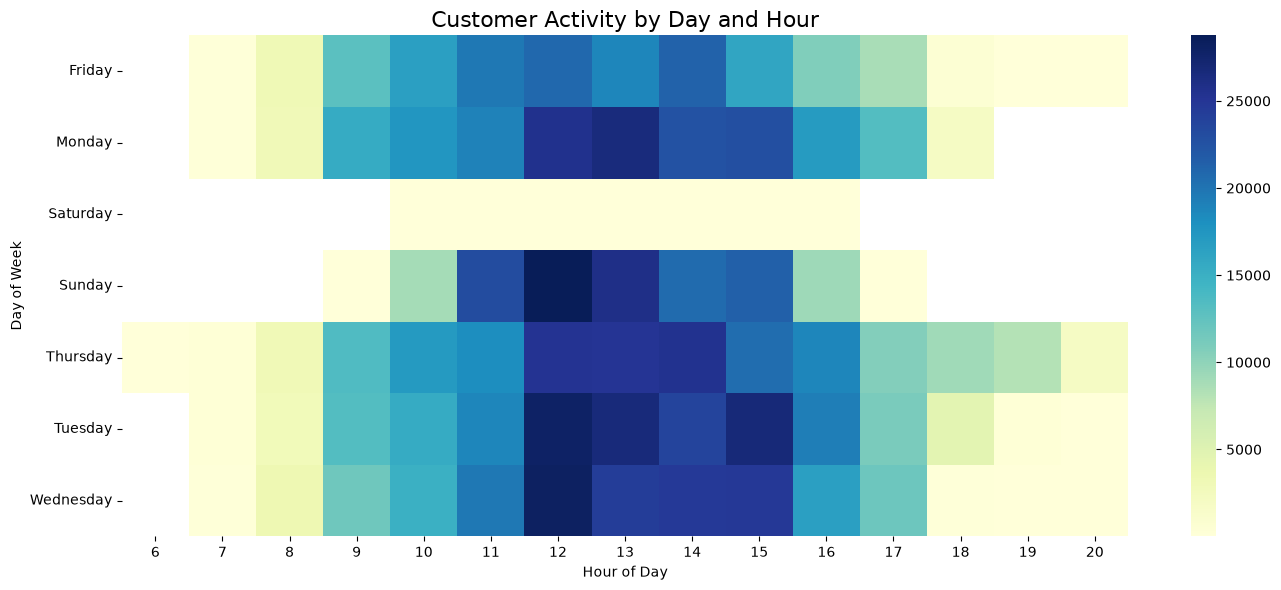

In [34]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Customer Activity by Day and Hour", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

In [35]:
reference_date = sales_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


C:\Users\yaswi\AppData\Local\Temp\ipykernel_23656\1276867152.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  reference_date = sales_df["InvoiceDate"].max() + pd.Timedelta(days=1)


In [36]:
rfm = (
    sales_df
    .groupby("Customer ID")
    .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [37]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616737
std,1715.572666,209.338707,13.009406,14737.731040
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


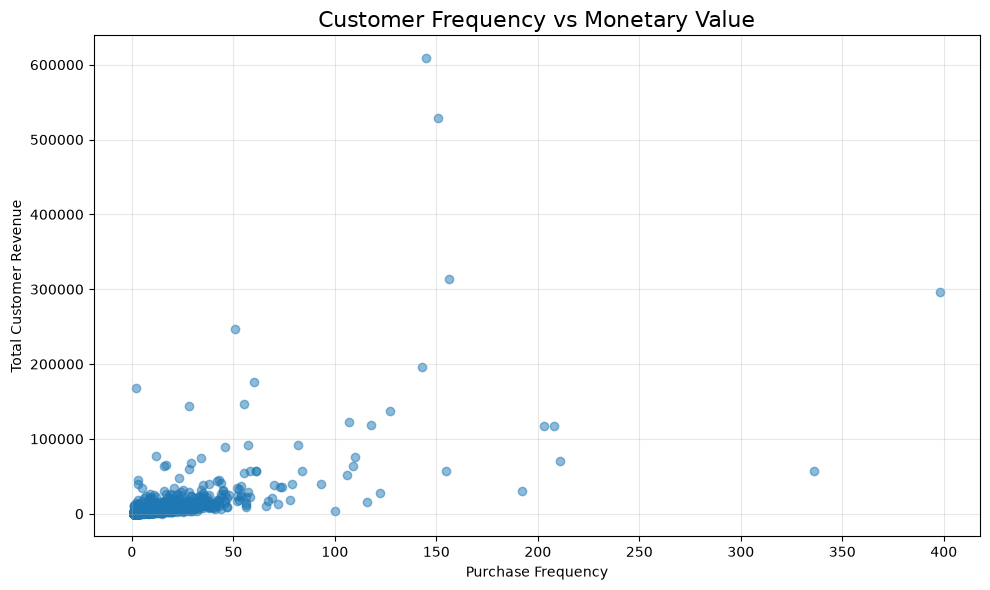

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    alpha=0.5
)

plt.title("Customer Frequency vs Monetary Value", fontsize=16)
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Customer Revenue")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

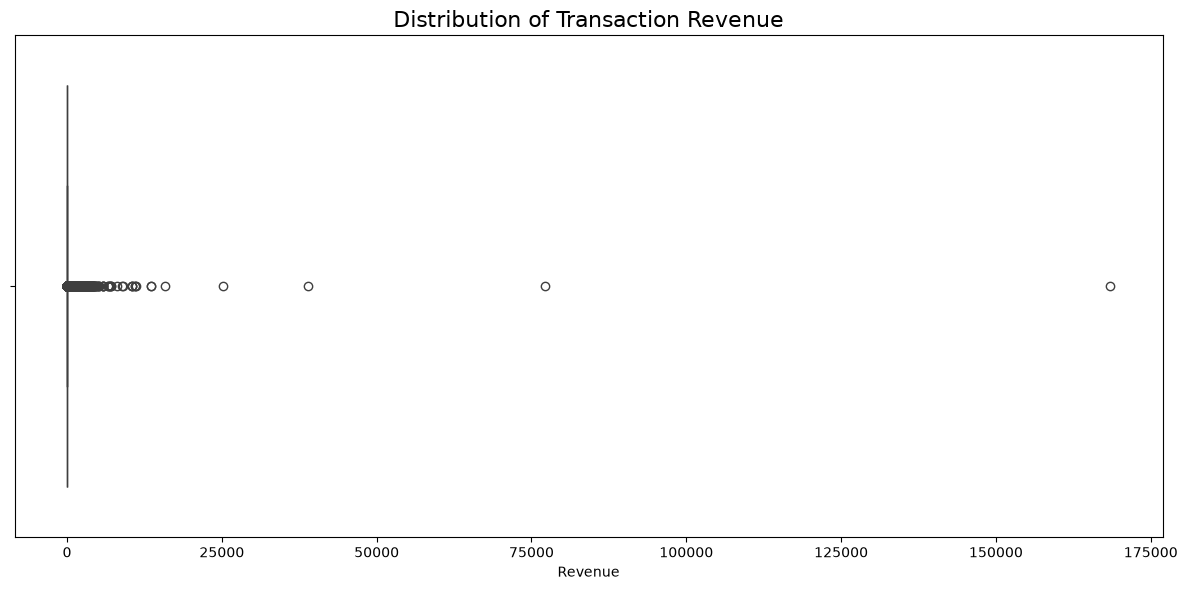

In [39]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x=sales_df["Revenue"]
)

plt.title("Distribution of Transaction Revenue", fontsize=16)
plt.xlabel("Revenue")

plt.tight_layout()
plt.show()

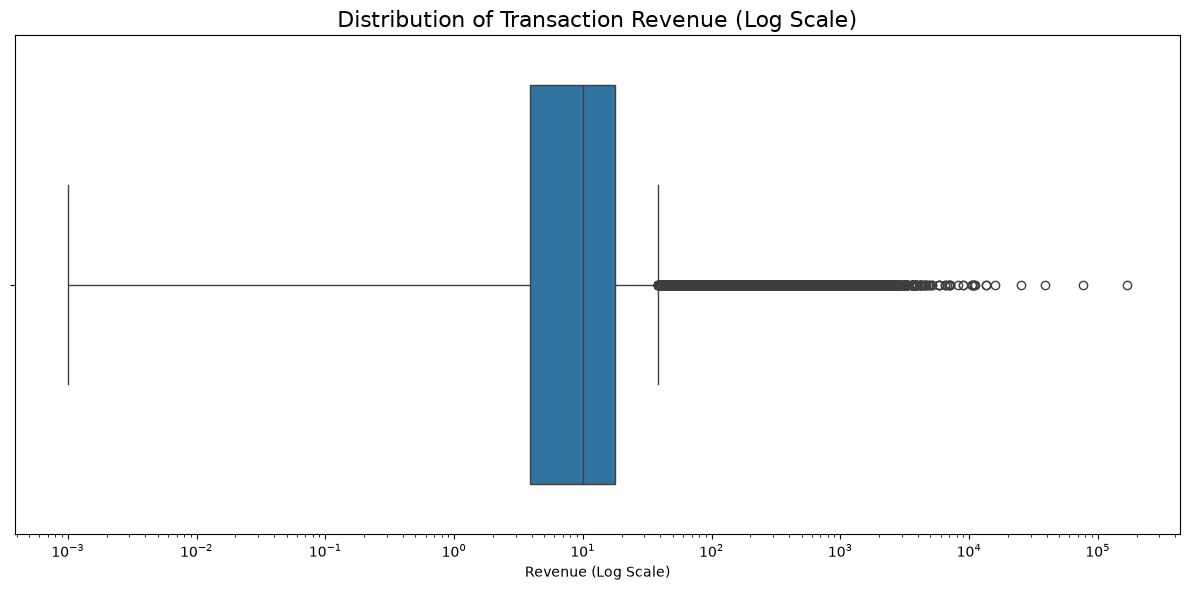

In [41]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x=sales_df["Revenue"]
)

plt.xscale("log")

plt.title("Distribution of Transaction Revenue (Log Scale)", fontsize=16)
plt.xlabel("Revenue (Log Scale)")

plt.tight_layout()
plt.show()

In [42]:
visualization_summary = pd.DataFrame({
    "Visualization": [
        "Monthly Revenue Trend",
        "Top 10 Countries by Revenue",
        "Top 10 Products by Revenue",
        "Customer Activity by Day and Hour",
        "Customer Frequency vs Monetary Value",
        "Transaction Revenue Distribution"
    ],
    "Chart Type": [
        "Line Chart",
        "Horizontal Bar Chart",
        "Horizontal Bar Chart",
        "Heatmap",
        "Scatter Plot",
        "Box Plot with Log Scale"
    ],
    "Purpose": [
        "Understand revenue changes over time",
        "Compare revenue across countries",
        "Identify products generating the highest revenue",
        "Identify periods of high customer activity",
        "Explore the relationship between purchase frequency and customer spending",
        "Identify the distribution and extreme transaction values"
    ]
})

visualization_summary

,Visualization,Chart Type,Purpose
0,Monthly Revenue Trend,Line Chart,Understand revenue changes over time
1,Top 10 Countries by Revenue,Horizontal Bar Chart,Compare revenue across countries
2,Top 10 Products by Revenue,Horizontal Bar Chart,Identify products generating the highest revenue
3,Customer Activity by Day and Hour,Heatmap,Identify periods of high customer activity
4,Customer Frequency vs Monetary Value,Scatter Plot,Explore the relationship between purchase freq...
5,Transaction Revenue Distribution,Box Plot with Log Scale,Identify the distribution and extreme transact...


In [43]:
print("===== MONTHLY REVENUE =====")

highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

print("Highest Revenue Month:")
print(highest_month)

print("\nLowest Revenue Month:")
print(lowest_month)


print("\n===== TOP 5 COUNTRIES =====")

print(country_revenue.head(5))


print("\n===== TOP 5 PRODUCTS =====")

print(product_revenue.head(5))


print("\n===== CUSTOMER RFM =====")

print("Number of customers:", len(rfm))

print("\nAverage Recency:")
print(rfm["Recency"].mean())

print("\nAverage Frequency:")
print(rfm["Frequency"].mean())

print("\nAverage Monetary Value:")
print(rfm["Monetary"].mean())


print("\n===== REVENUE DISTRIBUTION =====")

print("Median transaction revenue:")
print(sales_df["Revenue"].median())

print("Maximum transaction revenue:")
print(sales_df["Revenue"].max())

===== MONTHLY REVENUE =====
Highest Revenue Month:
Month      2011-11-01 00:00:00
Revenue             1509496.33
Name: 23, dtype: object

Lowest Revenue Month:
Month      2011-02-01 00:00:00
Revenue              523631.89
Name: 14, dtype: object

===== TOP 5 COUNTRIES =====
          Country       Revenue
0  United Kingdom  1.787135e+07
1            EIRE  6.644318e+05
2     Netherlands  5.542323e+05
3         Germany  4.312625e+05
4          France  3.569446e+05

===== TOP 5 PRODUCTS =====
                          Description    Revenue
0            REGENCY CAKESTAND 3 TIER  344563.25
1                              Manual  341104.90
2                      DOTCOM POSTAGE  322657.48
3  WHITE HANGING HEART T-LIGHT HOLDER  266923.55
4         PAPER CRAFT , LITTLE BIRDIE  168469.60

===== CUSTOMER RFM =====
Number of customers: 5878

Average Recency:
201.331915617557

Average Frequency:
6.289384144266758

Average Monetary Value:
3018.6167366451173

===== REVENUE DISTRIBUTION =====
Median t

## Visualization 1: Monthly Revenue Trend

### Business Question
How does revenue change over time?

### Why This Visualization?
A line chart was selected because it clearly shows changes in revenue across consecutive months and makes peaks and low periods easy to identify.

### Key Observation
The analysis shows that November 2011 recorded the highest monthly revenue at approximately £1.51 million. February 2011 recorded the lowest monthly revenue at approximately £0.52 million.

### Business Implication
The variation in monthly revenue indicates that sales performance changes considerably over time. Understanding these fluctuations can help businesses plan inventory, staffing, promotions, and other operational activities around periods of higher or lower demand.

### Caption
Figure 1. Monthly revenue trend showing changes in total positive transaction revenue over the analysis period.

## Visualization 2: Top 10 Countries by Revenue

### Business Question
Which countries contribute the most revenue?

### Why This Visualization?
A horizontal bar chart was selected because it provides a clear comparison between countries and makes differences in revenue easy to see.

### Key Observation
The United Kingdom generated approximately £17.87 million in revenue, substantially more than the other countries in the top five. EIRE generated approximately £0.66 million, followed by the Netherlands, Germany, and France.

### Business Implication
The analysis shows that revenue is highly concentrated in the United Kingdom. This information can help businesses understand their strongest geographic market while also identifying other countries that contribute meaningful revenue.

### Caption
Figure 2. Top 10 countries ranked according to total positive transaction revenue.

## Visualization 3: Top 10 Products by Revenue

### Business Question
Which products generate the highest revenue?

### Why This Visualization?
A horizontal bar chart was used because product names are categorical and can be compared directly by their total revenue.

### Key Observation
REGENCY CAKESTAND 3 TIER generated the highest product revenue at approximately £344,563.25, followed by Manual at approximately £341,104.90 and DOTCOM POSTAGE at approximately £322,657.48.

### Business Implication
Identifying high-revenue products can support inventory planning, product availability decisions, and sales strategy. These products may deserve closer monitoring because they contribute significantly to overall revenue.

### Caption
Figure 3. Top 10 products ranked by total positive transaction revenue.

## Visualization 4: Customer Activity by Day and Hour

### Business Question
When are customers most active?

### Why This Visualization?
A heatmap was selected because it allows two dimensions, day of week and hour of day, to be examined simultaneously. Darker areas represent periods with more transactions.

### Key Observation
Customer activity is concentrated mainly during daytime hours, with particularly strong activity around the middle of the day. The heatmap also shows differences in activity across days of the week.

### Business Implication
Understanding when transaction activity is highest can support staffing decisions, customer service planning, operational scheduling, and the timing of promotional activities.

### Caption
Figure 4. Heatmap showing transaction activity across different days and hours.

## Visualization 5: Customer Frequency vs Monetary Value

### Business Question
How does purchase frequency relate to customer spending?

### Why This Visualization?
A scatter plot was selected because it allows the relationship between two numerical customer-level measures to be examined. Each point represents a customer.

### Key Observation
Most customers are concentrated in the lower-frequency and lower-spending region. A smaller number of customers show substantially higher purchase frequency or monetary value, creating a long spread of customer behaviour.

### Business Implication
The variation in customer behaviour suggests that customers do not contribute equally to revenue. Businesses can use this information to identify high-value customers and develop appropriate retention or engagement strategies.

### Caption
Figure 5. Relationship between customer purchase frequency and total monetary value.

## Visualization 6: Distribution of Transaction Revenue

### Business Question
How are transaction revenues distributed, and are there unusually large transactions?

### Why This Visualization?
A box plot was selected because it summarizes the central distribution of transaction revenue while also highlighting potential outliers. A logarithmic scale was used to make the wide range of revenue values easier to inspect.

### Key Observation
The median transaction revenue is approximately £9.96, while the maximum transaction revenue reaches £168,469.60. The large difference between these values indicates the presence of a small number of unusually high-value transactions.

### Business Implication
Large transactions can have a significant effect on total revenue. Businesses may want to investigate these transactions separately because they could represent bulk purchases, unusually large orders, or other special purchasing behaviour.

### Caption
Figure 6. Distribution of transaction revenue using a logarithmic scale to highlight the wide range of transaction values.

# Week 2: Advanced Data Visualization and Storytelling with Python

## 1. Introduction

This project focuses on analysing the Online Retail II dataset using advanced data visualization and storytelling techniques. The dataset contains transaction-level information from an online retail business, including invoices, products, quantities, prices, dates, customer identifiers, and countries.

The main purpose of this analysis is not only to create charts, but also to use visualizations to communicate meaningful patterns in the data to a non-technical audience. Different visualization techniques were selected according to the type of question being investigated.

The analysis examines revenue trends over time, geographic revenue distribution, product performance, customer activity patterns, customer purchasing behaviour, and transaction-level revenue distribution. Together, these visualizations provide a broader view of the business and help transform a large transactional dataset into an understandable visual story.

## 2. Objectives

The main objectives of this project are:

1. Analyse the Online Retail II dataset using Python.
2. Prepare transaction data for visualization and analysis.
3. Develop at least five advanced visualizations using Matplotlib and Seaborn.
4. Identify important trends, patterns, and unusual observations.
5. Explain why each visualization was selected.
6. Communicate findings in a simple and understandable way for non-technical audiences.
7. Identify potential business implications from the analysis.
8. Develop a coherent data story connecting the different visualizations.
9. Document the complete analysis and findings in a structured report.

## 3. Dataset and Methodology

### 3.1 Dataset

The Online Retail II dataset was selected for this project. It contains online retail transaction records covering the period from 2009 to 2011.

The dataset includes the following important variables:

- Invoice: Invoice or transaction identifier
- StockCode: Product code
- Description: Product description
- Quantity: Number of units purchased
- InvoiceDate: Date and time of the transaction
- Price: Unit price
- Customer ID: Customer identifier
- Country: Customer's country

The two available yearly sheets were combined into a single dataset for analysis.

### 3.2 Data Preparation

The InvoiceDate column was converted into datetime format to support time-based analysis. A Revenue column was created by multiplying Quantity by Price.

For the main revenue analysis, transactions with positive Quantity and positive Price were retained. This allowed the analysis to focus on positive sales transactions rather than returns or cancellations.

The resulting sales dataset was then used to create monthly, country-level, product-level, customer-level, and transaction-level analyses.

### 3.3 Analytical Methods

The following techniques were used:

- Grouping and aggregation using Pandas
- Time-based analysis
- Country-level revenue analysis
- Product-level revenue analysis
- Day and hour transaction analysis
- RFM customer analysis
- Distribution and outlier analysis

Python libraries used in the project include Pandas, NumPy, Matplotlib, and Seaborn.

## 4. Overall Data Story

The visual analysis presents the Online Retail II dataset from several connected perspectives.

The first visualization shows that revenue changes considerably from month to month. November 2011 recorded the highest monthly revenue at approximately £1.51 million, while February 2011 recorded the lowest at approximately £0.52 million. This indicates that sales performance was not constant throughout the period.

The geographic analysis shows that the United Kingdom is the dominant revenue-generating market in the dataset, contributing approximately £17.87 million in positive transaction revenue. Other countries, including EIRE, the Netherlands, Germany, and France, contribute smaller but meaningful amounts.

The product analysis then moves from geography to individual products. REGENCY CAKESTAND 3 TIER generated the highest product revenue among the products analysed, followed by Manual and DOTCOM POSTAGE. This shows that revenue is not evenly distributed across all products.

The customer activity heatmap adds a time-of-day perspective. Transaction activity is concentrated mainly during daytime hours, with differences across days of the week. This provides useful information about when customers are most active.

The RFM-based customer analysis shows substantial variation in customer behaviour. Most customers are concentrated in the lower-frequency and lower-spending region, while a smaller number of customers show much higher monetary values or purchasing frequencies.

Finally, the transaction revenue distribution shows a strong difference between typical transactions and unusually large transactions. The median transaction revenue is approximately £9.96, while the maximum reaches £168,469.60. This demonstrates the presence of extreme high-value transactions.

Taken together, the visualizations tell a story about a business whose revenue varies over time, is strongly concentrated in one geographic market, depends on a subset of products and customers, and contains a small number of unusually large transactions.

## 5. Business Implications

The analysis provides several potential business implications.

### 5.1 Sales Planning

The monthly revenue trend can help businesses identify periods of relatively high and low sales activity. Historical patterns can support planning for inventory, staffing, and promotional activities.

### 5.2 Geographic Strategy

The strong contribution from the United Kingdom indicates that this market is particularly important within the dataset. At the same time, other countries contribute additional revenue and may represent opportunities for further analysis and market development.

### 5.3 Product Management

The top-product analysis identifies products that contribute substantial revenue. Monitoring the availability and performance of these products can support inventory and purchasing decisions.

### 5.4 Operational Planning

The day-and-hour heatmap provides information about when transaction activity is concentrated. This could support staffing, customer service, and operational scheduling decisions.

### 5.5 Customer Engagement

The RFM analysis demonstrates differences in customer purchasing behaviour. Businesses could use customer-level analysis to identify high-value customers and develop suitable retention and engagement strategies.

### 5.6 High-Value Transactions

The transaction revenue analysis identifies unusually large transactions. Such transactions may require separate investigation because they can have a significant effect on overall revenue.

## 6. Limitations

There are several limitations to this analysis.

First, the analysis is based on historical transaction data and therefore describes past purchasing behaviour rather than guaranteeing future behaviour.

Second, the analysis focuses mainly on transaction revenue and customer purchasing activity. Other factors such as marketing campaigns, product costs, profit margins, customer demographics, and external economic conditions were not included.

Third, the RFM analysis describes customer behaviour but does not establish causal relationships between purchase frequency and spending.

Finally, unusually large transactions were identified as potential outliers, but individual transactions were not investigated manually to determine the exact reason for each extreme value.

## 7. Conclusion

This project demonstrates how data visualization can transform a large retail transaction dataset into a clear and understandable business story.

Six different visualizations were developed to examine the data from multiple perspectives: time, geography, products, customer activity, customer behaviour, and transaction distribution. Each visualization was selected according to the question it was intended to answer.

The analysis identified several important patterns. Monthly revenue varied considerably, with November 2011 recording the highest monthly revenue. The United Kingdom represented the largest revenue-generating country in the dataset. A small group of products generated substantial revenue, while customer behaviour varied considerably between individuals. Transaction activity was concentrated during particular hours and days, and the revenue distribution showed a large number of relatively small transactions alongside a smaller number of very large transactions.

Overall, the project demonstrates that effective data storytelling is not simply about producing attractive charts. The value comes from connecting visual evidence with clear questions, observations, and potential business implications. Presenting the findings in this structured way makes the analysis more accessible to non-technical audiences and supports more informed business discussions.

## 8. Estimated Workload and Time Allocation

The Week 2 task was structured as a practical data visualization and storytelling exercise. The estimated effort was approximately 34 hours, distributed across data preparation, visualization development, interpretation, and documentation.

| Activity | Estimated Hours |
|---|---:|
| Data preparation and validation | 4 |
| Planning visualization questions and chart selection | 3 |
| Monthly revenue and country analysis | 4 |
| Product and customer activity visualizations | 5 |
| RFM customer analysis | 5 |
| Revenue distribution and outlier analysis | 3 |
| Data storytelling and interpretation | 4 |
| Report preparation and formatting | 4 |
| Final review and corrections | 2 |
| **Total** | **34 Hours** |

This allocation reflects the time required to experiment with different visualization approaches, interpret the results, document the reasoning behind each chart, and prepare the final submission.

## 9. References

1. Online Retail II dataset, publicly available through the UCI Machine Learning Repository.
2. Pandas documentation for data manipulation and aggregation.
3. Matplotlib documentation for data visualization.
4. Seaborn documentation for statistical visualization.

## 10. Submission Checklist

✓ Publicly accessible dataset selected  
✓ Dataset prepared for visualization  
✓ Revenue analysis completed  
✓ Six visualizations created  
✓ Multiple visualization types used  
✓ Each visualization explained  
✓ Chart-selection reasoning documented  
✓ Captions provided  
✓ Business implications discussed  
✓ Overall data story developed  
✓ Limitations documented  
✓ Conclusion included  
✓ Estimated 30–35 hour workload documented  
✓ References included  
✓ Notebook analysis completed  
✓ Final DOCX report ready for submission